# Módulo 2 — Movimiento Browniano Geométrico

**Proyecto:** Métodos de Monte Carlo en Finanzas Cuantitativas  
**Autor:** Jorge Rodríguez Lázaro  
**Última actualización:** 2026-07-14

---

## Objetivo del módulo

Este módulo construye el modelo estándar para el precio de un activo financiero: el **Movimiento Browniano Geométrico (GBM)**. Partimos de las dos piezas del Módulo 1 — la simulación Monte Carlo y el movimiento browniano — y las aplicamos al problema de modelar precios reales.

El objetivo es triple:

1. Entender de dónde sale la fórmula del GBM y por qué es el modelo natural para precios.
2. Simular trayectorias de precios y visualizar su comportamiento.
3. Estimar los parámetros del modelo ($\mu$ y $\sigma$) a partir de datos reales de mercado.

## Estructura

| Sección | Tema | Conexión con el proyecto |
|---------|------|--------------------------|
| 1 | Del paseo aleatorio al GBM | Por qué modelamos logaritmos y de dónde sale la fórmula. |
| 2 | Simulación de trayectorias | Discretización de Euler-Maruyama e implementación vectorizada. |
| 3 | Estimación de parámetros | Calibración de μ y σ con datos reales de Yahoo Finance. |
| 4 | Validación | Comparación entre trayectorias simuladas y precio histórico real. |

## Referencias

- Glasserman, P. (2003). *Monte Carlo Methods in Financial Engineering*, cap. 3.
- Hull, J. C. (2018). *Options, Futures and Other Derivatives*, cap. 15.
- Shreve, S. E. (2004). *Stochastic Calculus for Finance II*, cap. 4.

---

# Sección 1 — Del paseo aleatorio al GBM

## 1.1 Por qué no vale el movimiento browniano directo

El movimiento browniano $W_t$ tiene dos problemas como modelo de precios:

1. **Puede ser negativo.** $W_t \in \mathbb{R}$ para todo $t$, pero un precio $S_t > 0$ siempre.
2. **Los cambios son absolutos, no proporcionales.** En finanzas lo relevante es el cambio porcentual: una subida de 1€ en una acción de 10€ (10%) no es lo mismo que en una de 1000€ (0.1%). Un modelo aditivo no captura esto.

## 1.2 La solución: modelar las rentabilidades logarítmicas

Definimos la **rentabilidad logarítmica** entre dos instantes como:

$$
r_t = \log\frac{S_t}{S_{t-1}}
$$

Esta cantidad puede ser positiva o negativa (el precio sube o baja), no está acotada, y es **proporcional** al nivel del precio por construcción. Es el objeto natural a modelar.

El supuesto del GBM es que las rentabilidades logarítmicas son i.i.d. y normales:

$$
r_t \sim \mathcal{N}\!\left(\left(\mu - \frac{\sigma^2}{2}\right)\Delta t,\; \sigma^2 \Delta t\right)
$$

donde $\mu$ es la **rentabilidad esperada** (drift) y $\sigma$ es la **volatilidad**.

## 1.3 De las rentabilidades al precio: la fórmula del GBM

**Paso 1 — Una identidad exacta.** Dividimos $[0, T]$ en $N$ intervalos de longitud $\Delta t = T/N$. Los cocientes de precios se telescopan:

$$
\frac{S_T}{S_0} = \frac{S_1}{S_0} \cdot \frac{S_2}{S_1} \cdots \frac{S_N}{S_{N-1}}
\quad\Longrightarrow\quad
\log\frac{S_T}{S_0} = \sum_{i=1}^{N} r_i
$$

Esto no es un supuesto: es una igualdad algebraica que se cumple trayectoria a trayectoria, sea cual sea la evolución del precio.

**Paso 2 — La distribución de la suma.** Por el supuesto de 1.2, las $r_i$ son i.i.d. normales. Una suma de normales independientes es normal, y sus medias y varianzas se suman:

$$
\sum_{i=1}^{N} r_i \sim \mathcal{N}\!\left(N \left(\mu - \frac{\sigma^2}{2}\right)\Delta t,\; N \sigma^2 \Delta t\right) = \mathcal{N}\!\left(\left(\mu - \frac{\sigma^2}{2}\right)T,\; \sigma^2 T\right)
$$

**Paso 3 — De la tilde al igual.** Aquí hay un salto que conviene justificar: lo anterior es una afirmación *en distribución* ($\sim$), pero la fórmula final del GBM es una *igualdad* ($=$). El puente es general: si $X \sim \mathcal{N}(m, v)$, definimos

$$
Z := \frac{X - m}{\sqrt{v}}
$$

Como $Z$ es una transformación lineal de una normal, es normal, y calculando: $\mathbb{E}[Z] = 0$, $\operatorname{Var}(Z) = 1$. Despejando:

$$
X = m + \sqrt{v}\, Z, \qquad Z \sim \mathcal{N}(0, 1)
$$

y esto ya es una **igualdad entre variables aleatorias**, no solo en distribución: $Z$ no es un objeto nuevo e independiente, sino que está construida a partir de la propia $X$ — es la misma aleatoriedad, re-escalada para separar la parte determinista ($m$) del ruido puro ($Z$).

Aplicándolo a $X = \log(S_T/S_0)$ con $m = (\mu - \sigma^2/2)\,T$ y $v = \sigma^2 T$, y llamando $W_T := \sqrt{T}\, Z$ (que por construcción cumple $W_T \sim \mathcal{N}(0, T)$, exactamente la ley del movimiento browniano en el instante $T$ que vimos en el Módulo 1):

$$
\log\frac{S_T}{S_0} = \left(\mu - \frac{\sigma^2}{2}\right)T + \sigma W_T
$$

**Paso 4 — Despejar el precio.** La igualdad anterior vale realización a realización, así que podemos aplicar la exponencial a ambos lados:

$$
\boxed{S_T = S_0 \, \exp\!\left(\left(\mu - \frac{\sigma^2}{2}\right)T + \sigma W_T\right)}
$$

Toda la aleatoriedad de $S_T$ queda empaquetada en una única variable, $W_T$. De aquí sale directamente la receta de simulación: generar $Z \sim \mathcal{N}(0,1)$ y sustituir — es lo que haremos en la Sección 2.

## 1.4 La corrección $\sigma^2/2$ — corrección de Jensen

¿Por qué aparece $\mu - \sigma^2/2$ y no simplemente $\mu$?

Porque la esperanza de $e^X$ no es $e^{\mathbb{E}[X]}$ cuando $X$ es aleatoria. Si $X \sim \mathcal{N}(m, v)$:

$$
\mathbb{E}[e^X] = e^{m + v/2}
$$

Queremos que $\mathbb{E}[S_T] = S_0 \, e^{\mu T}$ — el precio crece en promedio a tasa $\mu$. Si ponemos $m = (\mu - \sigma^2/2)T$ y $v = \sigma^2 T$:

$$
\mathbb{E}[S_T] = S_0 \cdot e^{(\mu - \sigma^2/2)T + \sigma^2 T/2} = S_0 \, e^{\mu T} \checkmark
$$

El término $-\sigma^2/2$ compensa exactamente el exceso que introduce la exponencial, garantizando que la rentabilidad esperada del precio sea $\mu$ tal y como deseamos.

---

# Sección 2 — Simulación de trayectorias

## 2.1 La ecuación diferencial estocástica del GBM

En la Sección 1 llegamos a la fórmula del GBM acumulando rentabilidades logarítmicas discretas. La formulación continua del mismo modelo es una **ecuación diferencial estocástica (EDE)**:

$$
dS_t = \mu S_t\, dt + \sigma S_t\, dW_t
$$

La lectura es directa: en un intervalo infinitesimal, el cambio **proporcional** del precio

$$
\frac{dS_t}{S_t} = \mu\, dt + \sigma\, dW_t
$$

tiene una parte determinista ($\mu\,dt$, la tendencia) y una parte aleatoria ($\sigma\,dW_t$, ruido browniano escalado por la volatilidad). Es exactamente la idea de la Sección 1 — modelar cambios relativos, no absolutos — escrita en tiempo continuo.

La solución de esta EDE es la fórmula que ya conocemos:

$$
S_t = S_0 \exp\!\left(\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right)
$$

Demostrar que esta expresión resuelve la EDE requiere el **lema de Itô** (Shreve, cap. 4), que en este módulo tomamos como resultado. A cambio, lo verificaremos numéricamente por Monte Carlo en 2.4.

## 2.2 Dos esquemas de simulación

Para simular en una malla temporal $0 = t_0 < t_1 < \dots < t_N = T$ con paso $\Delta t = T/N$ hay dos caminos.

**Esquema exacto.** Aplicamos la fórmula cerrada entre nodos consecutivos. Como los incrementos del browniano son independientes y $W_{t_{k+1}} - W_{t_k} \sim \mathcal{N}(0, \Delta t)$:

$$
S_{k+1} = S_k \cdot \exp\!\left(\left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma \sqrt{\Delta t}\, Z_k\right), \qquad Z_k \overset{\text{iid}}{\sim} \mathcal{N}(0,1)
$$

Este esquema es **exacto en distribución** para cualquier $\Delta t$: los valores simulados en los nodos tienen exactamente la ley del GBM, sin error de discretización.

**Euler–Maruyama.** Es la receta general para *cualquier* EDE: sustituir $dt \to \Delta t$ y $dW_t \to \sqrt{\Delta t}\, Z_k$ directamente en la ecuación:

$$
S_{k+1} = S_k \left(1 + \mu\, \Delta t + \sigma \sqrt{\Delta t}\, Z_k\right)
$$

Este esquema **sí** tiene error de discretización (desaparece cuando $\Delta t \to 0$), e incluso puede producir precios negativos si $Z_k$ toma un valor muy negativo.

¿Por qué estudiar Euler–Maruyama si tenemos el esquema exacto? Porque el GBM es la excepción, no la regla: la mayoría de los modelos relevantes en la práctica (volatilidad estocástica, modelos de tipos de interés...) **no tienen solución cerrada**, y Euler es el caballo de batalla para simularlos. El GBM es el laboratorio perfecto para estudiar su error, porque disponemos de la respuesta exacta contra la que medirlo (lo haremos en 2.5).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm, norm

# Mismo generador reproducible que en el Módulo 1
rng = np.random.default_rng(seed=42)

In [2]:
def simular_gbm(S0, mu, sigma, T, n_pasos, n_tray, rng):
    """Simula trayectorias de GBM con el esquema exacto.

    Devuelve una matriz (n_tray, n_pasos + 1); la columna k contiene S_{t_k}.
    """
    dt = T / n_pasos
    # Matriz de rentabilidades logarítmicas: cada una ~ N((μ - σ²/2)Δt, σ²Δt)
    log_rent = rng.normal((mu - 0.5 * sigma**2) * dt, sigma * np.sqrt(dt),
                          size=(n_tray, n_pasos))
    # log S_k = log S_0 + suma acumulada de rentabilidades → exponenciamos
    log_S = np.log(S0) + np.cumsum(log_rent, axis=1)
    # Añadimos la columna inicial S_0
    return np.hstack([np.full((n_tray, 1), S0), np.exp(log_S)])

## 2.3 Trayectorias: la media no es la trayectoria típica

Simulamos trayectorias a 5 años y las comparamos con dos curvas teóricas:

- **Media:** $\mathbb{E}[S_t] = S_0\, e^{\mu t}$ — garantizada por la corrección de Jensen de 1.4.
- **Mediana:** $\operatorname{med}(S_t) = S_0\, e^{(\mu - \sigma^2/2)t}$. Como $\exp$ es estrictamente creciente, la mediana de $S_t = e^{X}$ es $e^{\operatorname{med}(X)}$, y la mediana de una normal es su media.

Que la mediana quede **por debajo** de la media es la asimetría lognormal en acción: unas pocas trayectorias explosivas tiran de la media hacia arriba, mientras que la trayectoria "típica" crece solo a tasa $\mu - \sigma^2/2$. De hecho, podemos calcular qué fracción de trayectorias termina por debajo de su propia media. Usando que $\log S_T \sim \mathcal{N}\big(\log S_0 + (\mu - \sigma^2/2)T,\; \sigma^2 T\big)$:

$$
P\big(S_T < \mathbb{E}[S_T]\big) = P\big(\log S_T < \log S_0 + \mu T\big) = \Phi\!\left(\frac{\sigma^2 T / 2}{\sigma\sqrt{T}}\right) = \Phi\!\left(\frac{\sigma \sqrt{T}}{2}\right) > \frac{1}{2}
$$

Con $\sigma = 0.2$ y $T = 5$: $\Phi(0.224) \approx 58.8\%$ de las trayectorias acaban por debajo de la media. Comprobamos ambas cosas en la celda siguiente.


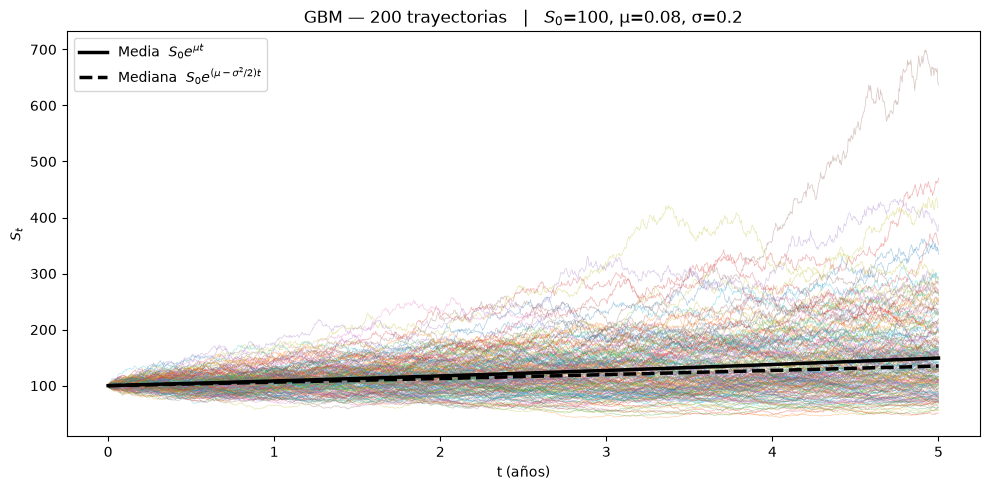

Fracción de trayectorias con S_T < E[S_T]:  0.595
Valor teórico Φ(σ√T/2):                     0.588


In [3]:
S0, MU, SIGMA = 100.0, 0.08, 0.20
T, N_PASOS    = 5.0, 5 * 252          # 5 años en pasos diarios
N_TRAY        = 200

tray  = simular_gbm(S0, MU, SIGMA, T, N_PASOS, N_TRAY, rng)
t_eje = np.linspace(0, T, N_PASOS + 1)

media_teo   = S0 * np.exp(MU * t_eje)
mediana_teo = S0 * np.exp((MU - 0.5 * SIGMA**2) * t_eje)

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(N_TRAY):
    ax.plot(t_eje, tray[i], linewidth=0.5, alpha=0.35)
ax.plot(t_eje, media_teo,   'k-',  linewidth=2.5, label=r'Media  $S_0 e^{\mu t}$')
ax.plot(t_eje, mediana_teo, 'k--', linewidth=2.5, label=r'Mediana  $S_0 e^{(\mu - \sigma^2/2)t}$')
ax.set_xlabel('t (años)')
ax.set_ylabel('$S_t$')
ax.set_title(f'GBM — {N_TRAY} trayectorias   |   $S_0$={S0:.0f}, μ={MU}, σ={SIGMA}')
ax.legend()
plt.tight_layout()
plt.show()

frac_debajo = np.mean(tray[:, -1] < S0 * np.exp(MU * T))
print(f"Fracción de trayectorias con S_T < E[S_T]:  {frac_debajo:.3f}")
print(f"Valor teórico Φ(σ√T/2):                     {norm.cdf(SIGMA * np.sqrt(T) / 2):.3f}")

## 2.4 Validación: $S_T$ es lognormal

La fórmula del GBM dice que $\log S_T \sim \mathcal{N}\big(\log S_0 + (\mu - \sigma^2/2)T,\; \sigma^2 T\big)$; es decir, $S_T$ sigue una distribución **lognormal**. Validamos el simulador con dos comprobaciones:

1. El histograma de $S_T$ simulado contra la densidad lognormal teórica.
2. Los momentos Monte Carlo contra los teóricos:

$$
\mathbb{E}[S_T] = S_0\, e^{\mu T}, \qquad \operatorname{Var}(S_T) = S_0^2\, e^{2\mu T}\left(e^{\sigma^2 T} - 1\right)
$$

(La varianza sale de aplicar $\mathbb{E}[e^X] = e^{m + v/2}$ a $\mathbb{E}[S_T^2]$ — el mismo truco de la corrección de Jensen en 1.4.)


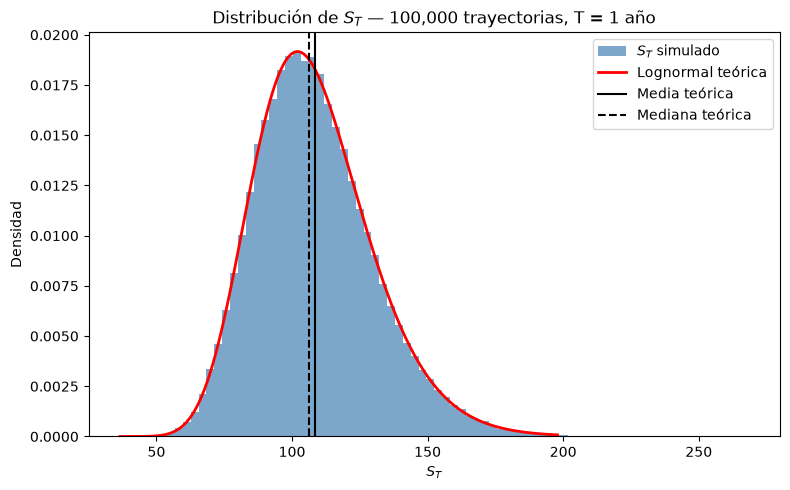

             Monte Carlo       Teórico
--------------------------------------
E[S_T]          108.3817      108.3287
DE(S_T)          21.9720       21.8842
Mediana         106.2741      106.1837


In [4]:
N_TRAY_VAL = 100_000
T_VAL      = 1.0

S_T = simular_gbm(S0, MU, SIGMA, T_VAL, 252, N_TRAY_VAL, rng)[:, -1]

# Lognormal en la convención de scipy:
#   s = desviación típica de log(S_T),  scale = exp(media de log(S_T))
dist_teo = lognorm(s=SIGMA * np.sqrt(T_VAL),
                   scale=S0 * np.exp((MU - 0.5 * SIGMA**2) * T_VAL))

x = np.linspace(S_T.min(), np.quantile(S_T, 0.999), 400)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(S_T, bins=80, density=True, color='steelblue', alpha=0.7, label='$S_T$ simulado')
ax.plot(x, dist_teo.pdf(x), 'r-', linewidth=2, label='Lognormal teórica')
ax.axvline(S0 * np.exp(MU * T_VAL), color='black', linestyle='-',  linewidth=1.5, label='Media teórica')
ax.axvline(dist_teo.median(),       color='black', linestyle='--', linewidth=1.5, label='Mediana teórica')
ax.set_xlabel('$S_T$')
ax.set_ylabel('Densidad')
ax.set_title(f'Distribución de $S_T$ — {N_TRAY_VAL:,} trayectorias, T = {T_VAL:.0f} año')
ax.legend()
plt.tight_layout()
plt.show()

de_teorica = np.sqrt(S0**2 * np.exp(2 * MU * T_VAL) * (np.exp(SIGMA**2 * T_VAL) - 1))
print(f"{'':10}  {'Monte Carlo':>12}  {'Teórico':>12}")
print("-" * 38)
print(f"{'E[S_T]':10}  {S_T.mean():>12.4f}  {S0 * np.exp(MU * T_VAL):>12.4f}")
print(f"{'DE(S_T)':10}  {S_T.std():>12.4f}  {de_teorica:>12.4f}")
print(f"{'Mediana':10}  {np.median(S_T):>12.4f}  {dist_teo.median():>12.4f}")

## 2.5 Midiendo el error de Euler–Maruyama

Para cuantificar el error de discretización usamos el **error fuerte**: la distancia media entre el valor final de Euler y el exacto, *construidos ambos con el mismo browniano*:

$$
e(\Delta t) = \mathbb{E}\big[\,\lvert S_T^{\text{Euler}} - S_T \rvert\,\big]
$$

La teoría (Kloeden & Platen) dice que Euler–Maruyama tiene **orden fuerte 1/2**: $e(\Delta t) = O(\Delta t^{1/2})$. Nótese que es peor que el orden 1 de Euler para EDOs deterministas — el ruido browniano degrada la convergencia.

El diseño del experimento sigue a Higham (*SIAM Review*, 2001): generamos los incrementos brownianos en la malla más fina y los **agregamos por bloques** para obtener *el mismo* browniano en mallas más gruesas. Así todas las discretizaciones comparten la misma fuente de aleatoriedad y la única diferencia entre ellas es $\Delta t$.


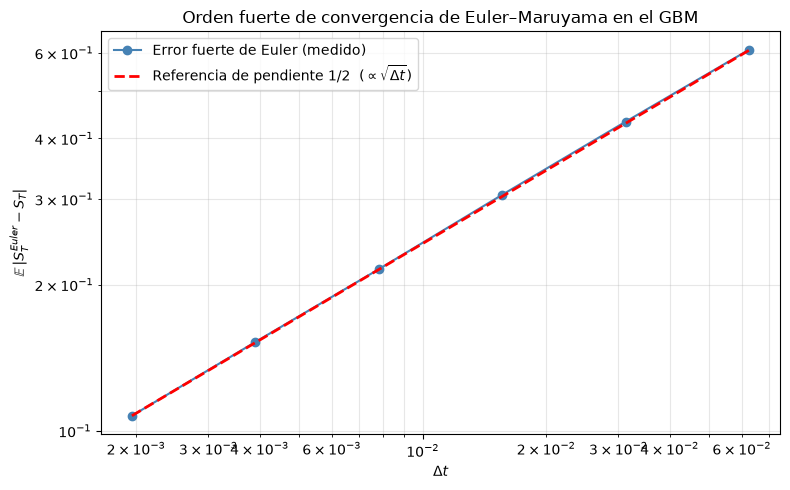

Pendiente ajustada en escala log-log: 0.501  (teórica: 0.5)


In [5]:
N_TRAY_ERR = 20_000
N_FINO     = 512                     # pasos de la malla más fina
T_ERR      = 1.0
dt_fino    = T_ERR / N_FINO

# Incrementos brownianos en la malla fina: ΔW ~ N(0, Δt)
dW = rng.normal(0, np.sqrt(dt_fino), size=(N_TRAY_ERR, N_FINO))

# Valor exacto de S_T con ese browniano: solo necesita W_T = suma de incrementos
W_T        = dW.sum(axis=1)
S_T_exacto = S0 * np.exp((MU - 0.5 * SIGMA**2) * T_ERR + SIGMA * W_T)

factores = [1, 2, 4, 8, 16, 32]      # factor de agrupado de la malla
dts, errores = [], []

for R in factores:
    n_pasos = N_FINO // R
    dt      = R * dt_fino
    # Sumar los incrementos finos en bloques de R → browniano en la malla gruesa
    dW_grueso = dW.reshape(N_TRAY_ERR, n_pasos, R).sum(axis=2)
    # Euler-Maruyama: S_{k+1} = S_k (1 + μΔt + σΔW_k) → producto de factores
    S_T_euler = S0 * np.prod(1 + MU * dt + SIGMA * dW_grueso, axis=1)
    dts.append(dt)
    errores.append(np.mean(np.abs(S_T_euler - S_T_exacto)))

dts, errores = np.array(dts), np.array(errores)

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(dts, errores, 'o-', color='steelblue', label='Error fuerte de Euler (medido)')
ax.loglog(dts, errores[0] * (dts / dts[0])**0.5, 'r--', linewidth=2,
          label=r'Referencia de pendiente 1/2  ($\propto \sqrt{\Delta t}$)')
ax.set_xlabel(r'$\Delta t$')
ax.set_ylabel(r'$\mathbb{E}\,|S_T^{Euler} - S_T|$')
ax.set_title('Orden fuerte de convergencia de Euler–Maruyama en el GBM')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

pendiente = np.polyfit(np.log(dts), np.log(errores), 1)[0]
print(f"Pendiente ajustada en escala log-log: {pendiente:.3f}  (teórica: 0.5)")

## 2.6 Recapitulación

Qué hemos establecido en esta sección:

1. La EDE del GBM, $dS_t = \mu S_t\, dt + \sigma S_t\, dW_t$, y su solución cerrada — verificada por Monte Carlo: media, mediana, desviación típica y distribución completa de $S_T$ coinciden con la teoría.
2. El **esquema exacto** de simulación, sin error de discretización, que será nuestro método por defecto siempre que trabajemos con GBM.
3. **Euler–Maruyama**, el esquema general para EDEs sin solución cerrada, y una medición empírica de su orden fuerte de convergencia $O(\sqrt{\Delta t})$.
4. Una lección conceptual importante: en un modelo lognormal, **la media no es la trayectoria típica** — la mayoría de las trayectorias quedan por debajo de $\mathbb{E}[S_t]$.

Hasta aquí, $\mu$ y $\sigma$ han sido números elegidos a mano. La pregunta natural de la **Sección 3** es: dados los precios históricos de un activo real, ¿cómo estimamos $\mu$ y $\sigma$? Ahí conectaremos el modelo con datos de mercado por primera vez.
